# Diffusion Model Training (next-day conditional)

Train a conditional diffusion model that learns the next-day IV surface
distribution given the current-day surface,

- historical: consecutive trading days from the chronologically-ordered
  training slice.
- heston / sabr: consecutive simulation steps within paths assigned
  to the training split (paths are disjoint between train and validation).

- Transformer backbone
                                                 

In [ ]:
import json
import time
from pathlib import Path

import copy
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm

from implied_volatility_diffusion import (
    ArbitragePenalty,
    ArbitrageWeights,
    DiffusionLoss,
    DiffusionLossConfig,
    DiffusionModel,
    UnifiedGrid,
    VPNoiseScheduler,
    GridTransformer,
)

plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 110, "axes.grid": False})


def _select_device() -> torch.device:
    """Prefer Apple Silicon MPS, then CUDA, then CPU."""
    if torch.backends.mps.is_available() and torch.backends.mps.is_built():
        return torch.device("mps")
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")


DEVICE = _select_device()
print(f"compute device: {DEVICE}")

In [2]:
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
CFG_DIR = REPO_ROOT / "config"
DATASET_ROOT = REPO_ROOT / "data" / "processed" / "forecasting_dataset"
CHECKPOINT_DIR = REPO_ROOT / "data" / "processed" / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

GRID = UnifiedGrid.load(CFG_DIR / "unified_iv_grid.yaml")
print("unified grid:", GRID.shape)

if not (DATASET_ROOT / "manifest.json").exists():
    raise FileNotFoundError(
        f"missing {DATASET_ROOT / 'manifest.json'}; "
        "run notebooks/unified_surface_pipeline.ipynb first to materialise the training pool"
    )

unified grid: (41, 40)


##  Load training and validation pair stacks



In [ ]:
manifest = json.loads((DATASET_ROOT / "manifest.json").read_text())
print("dataset manifest:", json.dumps(manifest, indent=2))

TRAIN_DIR = REPO_ROOT / manifest["splits"]["train"]
VAL_DIR = REPO_ROOT / manifest["splits"]["val"]
normalizer_stats = np.load(DATASET_ROOT / "normalizer.npz")
normalizer_mean = normalizer_stats["mean"].astype(np.float32)
normalizer_std = normalizer_stats["std"].astype(np.float32)
normalizer_iv_floor = float(normalizer_stats.get("iv_floor", 1e-8))
normalizer_stats.close()

#  Training pair stack
pair_curr = np.load(TRAIN_DIR / "pair_curr.npy").astype(np.float32)  # S_t
pair_next = np.load(TRAIN_DIR / "pair_next.npy").astype(np.float32)  # S_{t+1}
assert pair_curr.shape == pair_next.shape, f"train curr/next shape mismatch: {pair_curr.shape} vs {pair_next.shape}"
n_total = int(pair_curr.shape[0])

#  Validation pair stack (held out, not used to update weights)
val_pair_curr = np.load(VAL_DIR / "pair_curr.npy").astype(np.float32)
val_pair_next = np.load(VAL_DIR / "pair_next.npy").astype(np.float32)
val_pair_sources = np.load(VAL_DIR / "pair_sources.npy")
assert val_pair_curr.shape == val_pair_next.shape

## Trainig config

In [4]:
NUM_EPOCHS = 50
BATCH_SIZE = 32
LR = 2e-4
WEIGHT_DECAY = 1e-2
GRAD_CLIP = 1.0
VAL_FRAC = 0.2
SEED = 42

SCHEDULER_TIMESTEPS = 400
ARBITRAGE_LAMBDA = 0.05
ARBITRAGE_SCHEDULE = "alpha_bar"
SMOOTHNESS_LAMBDA = 2e-3
SMOOTHNESS_SCHEDULE = "constant"
SNR_WEIGHTING = True
SPOT_REF = 100.0
RATE_REF = 0.03

TRANSFORMER_KWARGS = dict(
    grid_shape=tuple(GRID.shape),
    in_channels=1,
    out_channels=1,
    cond_channels=1,
    d_model=128,
    nhead=4,
    layers=4,
    dim_feedforward=512,
    dropout=0.1,
    time_embedding_dim=128,
)

steps_per_epoch = max(int(np.ceil(n_total * (1 - VAL_FRAC) / BATCH_SIZE)), 1)
total_steps = NUM_EPOCHS * steps_per_epoch
warmup_steps = max(1, int(0.03 * total_steps))

print(f"steps per epoch: {steps_per_epoch}, total steps: {total_steps}, warmup steps: {warmup_steps}")

steps per epoch: 183, total steps: 9150, warmup steps: 274


## Build model, scheduler, loss and optimiser

##  Train / Validation Split


In [ ]:
pair_next_t = torch.from_numpy(pair_next).unsqueeze(1)
pair_curr_t = torch.from_numpy(pair_curr).unsqueeze(1)
pin_memory = DEVICE.type == "cuda"

if pin_memory:
    pair_next_t = pair_next_t.pin_memory()
    pair_curr_t = pair_curr_t.pin_memory()

# Load source labels from TRAINING data (not val) for stratified split
train_pair_sources = np.load(TRAIN_DIR / "pair_sources.npy")

rng = np.random.default_rng(SEED + 999)
val_idx_chunks = []

for src_id in np.unique(train_pair_sources):
    src_idx = np.flatnonzero(train_pair_sources == src_id)
    rn_val_src = max(1, int(len(src_idx) * VAL_FRAC))
    val_idx_chunks.append(rng.choice(src_idx, size=rn_val_src, replace=False))

val_indices = np.sort(np.concatenate(val_idx_chunks))
val_mask = np.zeros(n_total, dtype=bool)
val_mask[val_indices] = True

train_indices = np.flatnonzero(~val_mask)

print(f"train/val split: {len(train_indices)} / {len(val_indices)}")


def iter_batches(
    indices: np.ndarray,
    *,
    shuffle: bool,
    rng_: np.random.Generator,
) -> torch.Tensor:
    order = rng_.permutation(indices) if shuffle else indices
    for start in range(0, len(indices), BATCH_SIZE):
        yield order[start : start + BATCH_SIZE]

In [ ]:
torch.manual_seed(SEED)
np.random.seed(SEED)

scheduler = VPNoiseScheduler(timesteps=SCHEDULER_TIMESTEPS, beta_schedule="cosine")
backbone = GridTransformer(**TRANSFORMER_KWARGS)
model = DiffusionModel(
    backbone=backbone,
    scheduler=scheduler,
    mean=normalizer_mean,
    std=normalizer_std,
    iv_floor=normalizer_iv_floor,
    prediction_type="x0",
).to(DEVICE)

# Use up to 2 CUDA devices (e.g., dual T4) by parallelizing the backbone only.
if DEVICE.type == "cuda":
    n_cuda = torch.cuda.device_count()
    n_used = min(2, n_cuda)
    if n_used > 1:
        model.backbone = torch.nn.DataParallel(model.backbone, device_ids=list(range(n_used)))
        print(f"using DataParallel across {n_used} CUDA devices")
    else:
        print(f"single CUDA device detected: {n_cuda}")

penalty = ArbitragePenalty(
    log_moneyness=GRID.log_moneyness,
    tau=GRID.tau,
    spot=SPOT_REF,
    rate=RATE_REF,
    weights=ArbitrageWeights(),
)

loss_fn = DiffusionLoss(
    penalty,
    config=DiffusionLossConfig(
        arbitrage_lambda=ARBITRAGE_LAMBDA,
        arbitrage_schedule=ARBITRAGE_SCHEDULE,
        smoothness_lambda=SMOOTHNESS_LAMBDA,
        smoothness_schedule=SMOOTHNESS_SCHEDULE,
        snr_weighting=SNR_WEIGHTING,
    ),
).to(DEVICE)


def split_params_for_decay(
    module: torch.nn.Module,
) -> tuple[list[torch.nn.Parameter], list[torch.nn.Parameter]]:
    decay, no_decay = [], []
    for name, param in module.named_parameters():
        if not param.requires_grad:
            continue
        if param.ndim <= 1 or name.endswith(".bias"):
            no_decay.append(param)
        else:
            decay.append(param)
    return decay, no_decay


decay_params, no_decay_params = split_params_for_decay(model)
optimizer = torch.optim.AdamW(
    [
        {"params": decay_params, "weight_decay": WEIGHT_DECAY},
        {"params": no_decay_params, "weight_decay": 0.0},
    ],
    lr=LR,
)


def lr_lambda(current_step: int) -> float:
    if current_step < warmup_steps:
        return float(current_step + 1) / max(1, warmup_steps)
    progress = (current_step - warmup_steps) / float(max(1, total_steps - warmup_steps))
    progress = min(max(progress, 0.0), 1.0)
    return 0.05 + 0.95 * 0.5 * (1.0 + math.cos(math.pi * progress))


lr_scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"model parameters: {n_params:,}")

## Model training

In [ ]:
@torch.no_grad()
def evaluate() -> dict[str, float]:
    model.eval()
    vals = []
    eval_rng = torch.Generator().manual_seed(SEED + 1234)
    for idx in iter_batches(val_indices, shuffle=False, rng_=rng):
        iv_next = pair_next_t[idx].to(DEVICE, non_blocking=pin_memory)
        iv_curr = pair_curr_t[idx].to(DEVICE, non_blocking=pin_memory)
        cond_z = model.normalize(iv_curr)
        t = torch.randint(0, scheduler.timesteps, (iv_next.shape[0],), generator=eval_rng).to(DEVICE)
        noise = torch.randn(iv_next.shape, generator=eval_rng).to(DEVICE)
        out = loss_fn(model, iv_next, t=t, noise=noise, cond=cond_z)
        vals.append({k: float(v.detach().cpu()) for k, v in out.items() if torch.is_tensor(v)})

    model.train()
    return {
        "val_loss": float(np.mean([v["loss"] for v in vals])),
        "val_loss_eps": float(np.mean([v["loss_eps"] for v in vals])),
        "val_loss_smooth": float(np.mean([v.get("loss_smooth", 0) for v in vals])),
        "val_loss_arb": float(np.mean([v.get("loss_arb", 0) for v in vals])),
    }

In [ ]:
history = []
step_history = []
best_val = float("inf")
best_state = None
best_epoch = 0
global_step = 0
rng = np.random.default_rng(SEED + 2024)
t0 = time.perf_counter()

model.train()
for epoch in tqdm(range(1, NUM_EPOCHS + 1), desc="epochs"):
    train_loss = []
    train_eps = []
    train_smooth = []
    train_arb = []

    for idx in tqdm(iter_batches(train_indices, shuffle=True, rng_=rng), total=steps_per_epoch, leave=False):
        iv_next = pair_next_t[idx].to(DEVICE, non_blocking=pin_memory)
        iv_curr = pair_curr_t[idx].to(DEVICE, non_blocking=pin_memory)

        with torch.no_grad():
            cond_z = model.normalize(iv_curr)

        optimizer.zero_grad(set_to_none=True)
        out = loss_fn(model, iv_next, cond=cond_z)
        loss = out["loss"]

        if not torch.isfinite(loss):
            continue

        loss.backward()
        grad_norm = float(torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP).detach().cpu())
        optimizer.step()

        lr_scheduler.step()

        step_loss = float(out["loss"].detach().cpu())
        step_eps = float(out["loss_eps"].detach().cpu())
        step_smooth = float(out.get("loss_smooth", torch.zeros(())).detach().cpu())
        step_arb = float(out.get("loss_arb", torch.zeros(())).detach().cpu())

        train_loss.append(step_loss)
        train_eps.append(step_eps)
        train_smooth.append(step_smooth)
        train_arb.append(step_arb)

        step_history.append(
            {
                "step": global_step,
                "loss": step_loss,
                "loss_eps": step_eps,
                "loss_smooth": step_smooth,
                "loss_arb": step_arb,
                "lr": float(optimizer.param_groups[0]["lr"]),
                "grad_norm": grad_norm,
            }
        )
        global_step += 1

    val_metrics = evaluate()
    row = {
        "epoch": epoch,
        "step": global_step,
        "loss": float(np.mean(train_loss)),
        "loss_eps": float(np.mean(train_eps)),
        "loss_smooth": float(np.mean(train_smooth)),
        "loss_arb": float(np.mean(train_arb)),
        "lr": float(optimizer.param_groups[0]["lr"]),
        "elapsed_s": time.perf_counter() - t0,
        **val_metrics,
    }

    history.append(row)
    print(
        f"epoch {epoch:03d} loss={row['loss']:.4f} val={row['val_loss']:.4f} "
        f"eps={row['loss_eps']:.4f} smth={row['loss_smooth']:.4f} arb={row['loss_arb']:.4f}"
    )

    if np.isfinite(row["val_loss"]) and row["val_loss"] < best_val:
        best_val = row["val_loss"]
        best_state = copy.deepcopy(model.state_dict())
        best_epoch = epoch

if best_state is not None:
    model.load_state_dict(best_state)

history_df = pd.DataFrame(history)
step_history_df = pd.DataFrame(step_history)
epoch_history_df = history_df.rename(
    columns={
        "loss": "loss_mean",
        "loss_eps": "loss_eps_mean",
        "loss_smooth": "loss_smooth_mean",
        "loss_arb": "loss_arb_mean",
    }
)
display(history_df.tail(10))

## Training Curve

NameError: name 'history_df' is not defined

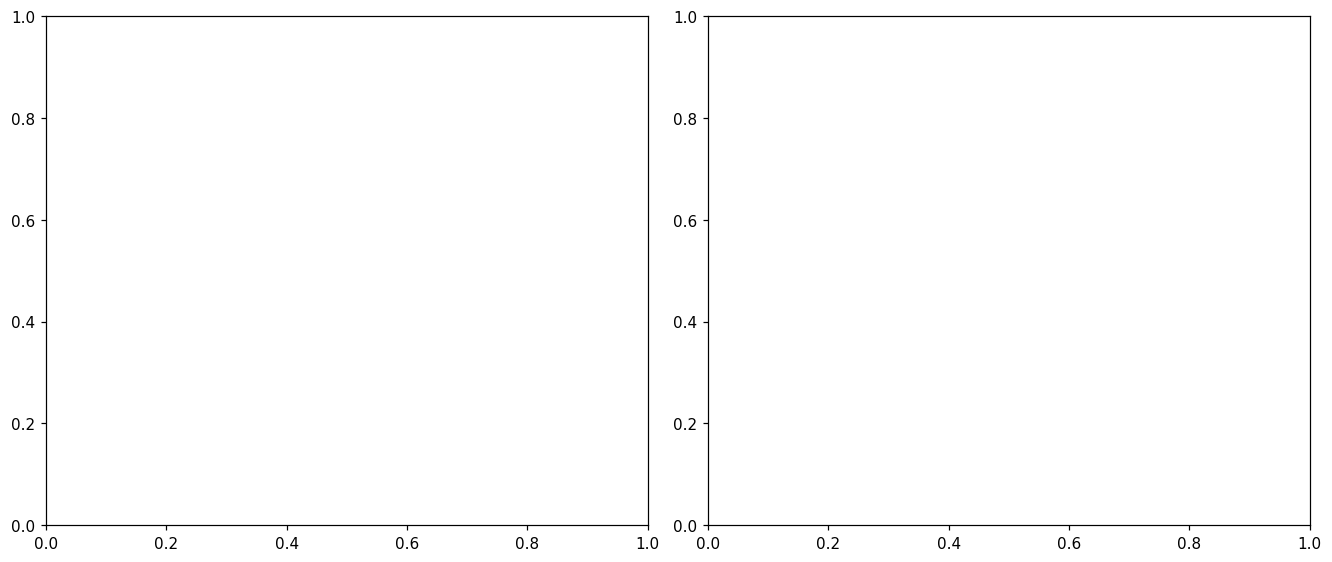

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
axes[0].plot(history_df["epoch"], history_df["loss"], label="train")
axes[0].plot(history_df["epoch"], history_df["val_loss"], label="validation")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(history_df["epoch"], history_df["loss_eps"], label="train eps")
axes[1].plot(history_df["epoch"], history_df["val_loss_eps"], label="validation eps")
axes[1].plot(history_df["epoch"], history_df["loss_arb"], label="train arb")
axes[1].plot(history_df["epoch"], history_df["val_loss_arb"], label="validation arb")
axes[1].set_title("Loss Components")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
plt.show()

## plots

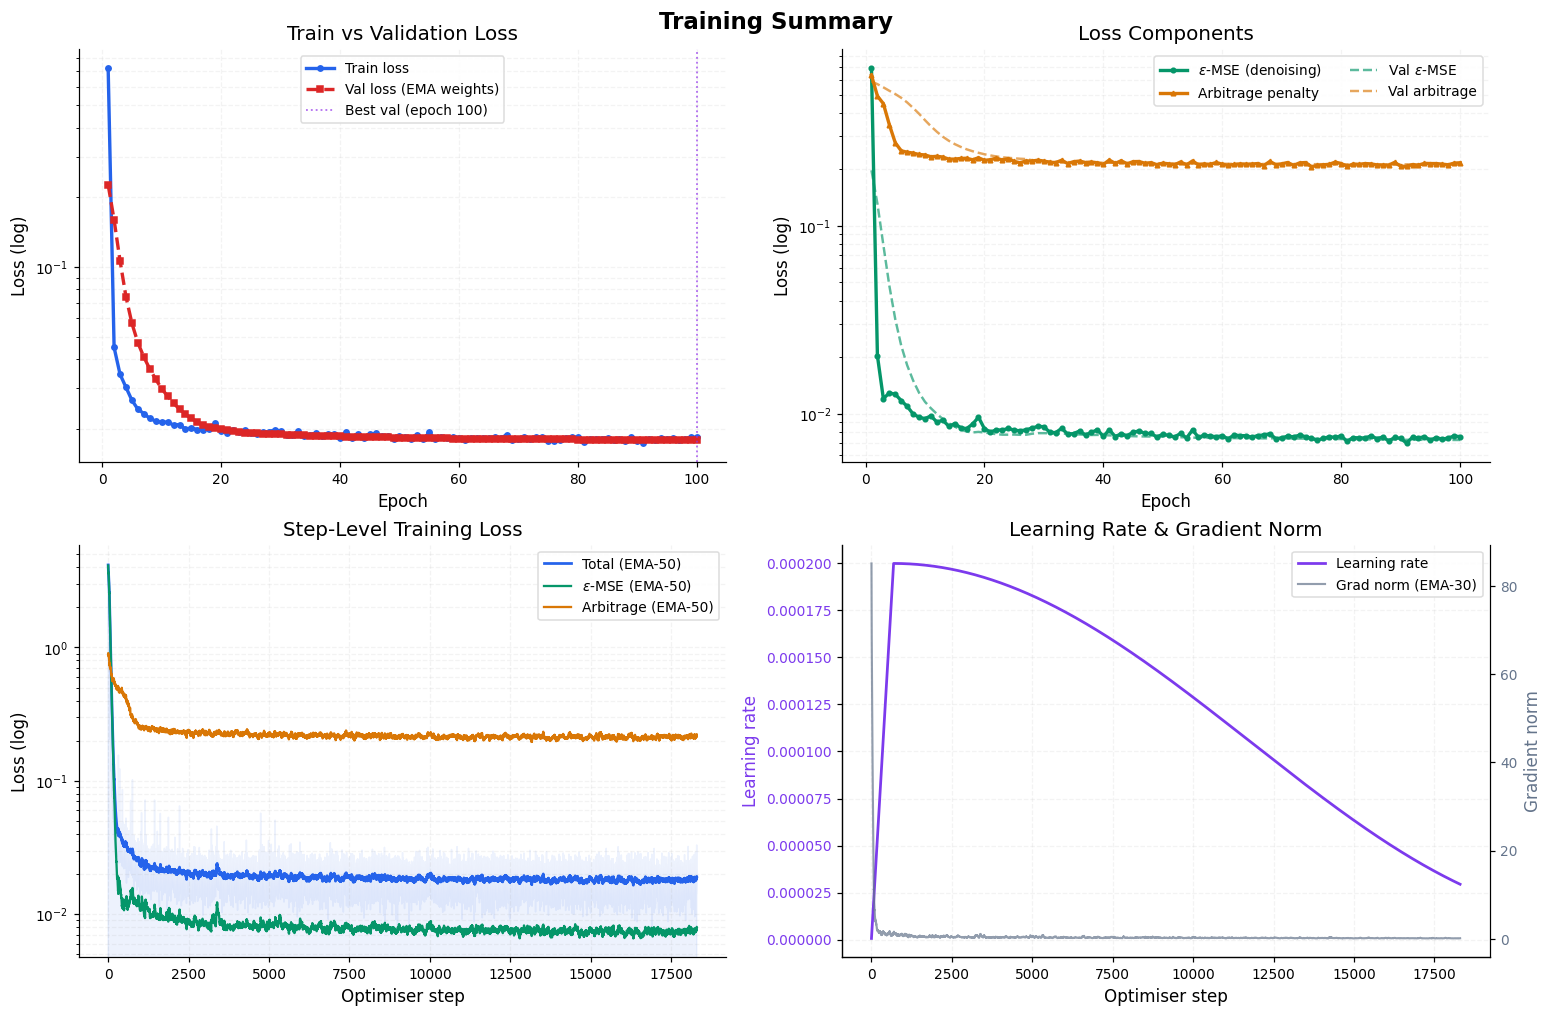

In [ ]:
def _ema(series: np.ndarray, span: int = 50) -> np.ndarray:
    return pd.Series(series).ewm(span=span, adjust=False).mean().to_numpy()


_STYLE = {
    "font.family": "sans-serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.labelsize": 11,
    "axes.titlesize": 13,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.framealpha": 0.9,
    "legend.edgecolor": "0.85",
}

with plt.rc_context(_STYLE):
    epochs = epoch_history_df["epoch"].to_numpy()
    steps_arr = step_history_df["step"].to_numpy()

    fig, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
    ax.plot(
        epochs, epoch_history_df["loss_mean"], lw=2.2, color="#2563eb", marker="o", markersize=3.5, label="Train loss"
    )
    if "val_loss" in epoch_history_df.columns and epoch_history_df["val_loss"].notna().any():
        ax.plot(
            epochs,
            epoch_history_df["val_loss"],
            lw=2.2,
            color="#dc2626",
            marker="s",
            markersize=3.5,
            linestyle=" ",
            label="Val loss (EMA weights)",
        )
    if best_epoch > 0:
        ax.axvline(best_epoch, color="#9333ea", ls=":", lw=1.2, alpha=0.7, label=f"Best val (epoch {best_epoch})")
    ax.set_yscale("log")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss (log)")
    ax.set_title("Train vs Validation Loss")
    ax.legend()
    ax.grid(alpha=0.15, which="both", ls=" ")
    fig.savefig("training_loss_train_vs_val.pdf", format="pdf", bbox_inches="tight")
    plt.show()

    fig, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
    ax.plot(
        epochs,
        epoch_history_df["loss_eps_mean"],
        lw=2.2,
        color="#059669",
        marker="o",
        markersize=3,
        label=r"$\epsilon$-MSE (denoising)",
    )
    if "loss_smooth_mean" in epoch_history_df.columns:
        ax.plot(
            epochs,
            epoch_history_df["loss_smooth_mean"],
            lw=2.2,
            color="#0891b2",
            marker="d",
            markersize=3,
            label="Smoothness (Dirichlet)",
        )
    ax.plot(
        epochs,
        epoch_history_df["loss_arb_mean"],
        lw=2.2,
        color="#d97706",
        marker="^",
        markersize=3,
        label="Arbitrage penalty",
    )
    if "val_loss_eps" in epoch_history_df.columns:
        ax.plot(
            epochs,
            epoch_history_df["val_loss_eps"],
            lw=1.6,
            color="#059669",
            ls=" ",
            alpha=0.65,
            label=r"Val $\epsilon$-MSE",
        )
    if "val_loss_arb" in epoch_history_df.columns:
        ax.plot(
            epochs,
            epoch_history_df["val_loss_arb"],
            lw=1.6,
            color="#d97706",
            ls=" ",
            alpha=0.65,
            label="Val arbitrage",
        )
    if "val_loss_smooth" in epoch_history_df.columns:
        ax.plot(
            epochs,
            epoch_history_df["val_loss_smooth"],
            lw=1.6,
            color="#0891b2",
            ls=" ",
            alpha=0.65,
            label="Val smoothness",
        )
    ax.set_yscale("log")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss (log)")
    ax.set_title("Loss Components")
    ax.legend(ncols=2)
    ax.grid(alpha=0.15, which="both", ls=" ")
    fig.savefig("training_loss_components.pdf", format="pdf", bbox_inches="tight")
    plt.show()

    fig, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
    ax.fill_between(steps_arr, step_history_df["loss"], alpha=0.08, color="#2563eb")
    ax.plot(steps_arr, _ema(step_history_df["loss"].to_numpy()), lw=1.8, color="#2563eb", label="Total (EMA-50)")
    ax.plot(
        steps_arr,
        _ema(step_history_df["loss_eps"].to_numpy()),
        lw=1.5,
        color="#059669",
        label=r"$\epsilon$-MSE (EMA-50)",
    )
    if "loss_smooth" in step_history_df.columns:
        ax.plot(
            steps_arr,
            _ema(step_history_df["loss_smooth"].to_numpy()),
            lw=1.5,
            color="#0891b2",
            label="Smoothness (EMA-50)",
        )
    ax.plot(
        steps_arr, _ema(step_history_df["loss_arb"].to_numpy()), lw=1.5, color="#d97706", label="Arbitrage (EMA-50)"
    )
    ax.set_yscale("log")
    ax.set_xlabel("Optimiser step")
    ax.set_ylabel("Loss (log)")
    ax.set_title("Step-Level Training Loss")
    ax.legend()
    ax.grid(alpha=0.15, which="both", ls=" ")
    fig.savefig("training_loss_step_level.pdf", format="pdf", bbox_inches="tight")
    plt.show()

    fig, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
    color_lr, color_gn = "#7c3aed", "#64748b"
    ax.plot(steps_arr, step_history_df["lr"], lw=1.8, color=color_lr, label="Learning rate")
    ax.set_xlabel("Optimiser step")
    ax.set_ylabel("Learning rate", color=color_lr)
    ax.tick_params(axis="y", labelcolor=color_lr)
    ax.grid(alpha=0.15, which="both", ls=" ")

    ax2 = ax.twinx()
    ax2.plot(
        steps_arr,
        _ema(step_history_df["grad_norm"].to_numpy(), span=30),
        lw=1.4,
        color=color_gn,
        alpha=0.7,
        label="Grad norm (EMA-30)",
    )
    ax2.set_ylabel("Gradient norm", color=color_gn)
    ax2.tick_params(axis="y", labelcolor=color_gn)
    ax2.spines["right"].set_visible(True)
    ax2.spines["top"].set_visible(False)
    ax.set_title("Learning Rate & Gradient Norm")
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc="upper right")
    fig.savefig("training_loss_lr_grad_norm.pdf", format="pdf", bbox_inches="tight")
    plt.show()

## Save checkpoint

Persist the trained weights, optimiser state, loss histories

In [ ]:
checkpoint_path = CHECKPOINT_DIR / "diffusion_transformer.pt"
config_path = CHECKPOINT_DIR / "transformer_training_config.json"
history_path = CHECKPOINT_DIR / "training_history.csv"

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "backbone": "grid_transformer",
        "scheduler_timesteps": SCHEDULER_TIMESTEPS,
        "transformer_kwargs": TRANSFORMER_KWARGS,
        "grid_shape": tuple(GRID.shape),
        "num_epochs": NUM_EPOCHS,
        "batch_size": BATCH_SIZE,
        "lr": LR,
        "arbitrage_lambda": ARBITRAGE_LAMBDA,
        "arbitrage_schedule": ARBITRAGE_SCHEDULE,
        "spot_ref": SPOT_REF,
        "rate_ref": RATE_REF,
        "seed": SEED,
        "conditional": True,
        "cond_channels": int(TRANSFORMER_KWARGS.get("cond_channels", 0)),
        "prediction_type": model.prediction_type,
        "best_val": best_val,
    },
    checkpoint_path,
)
config_path.write_text(
    json.dumps(
        {
            "backbone": "grid_transformer",
            "transformer_kwargs": TRANSFORMER_KWARGS,
            "num_epochs": NUM_EPOCHS,
            "batch_size": BATCH_SIZE,
            "lr": LR,
            "scheduler_timesteps": SCHEDULER_TIMESTEPS,
            "arbitrage_lambda": ARBITRAGE_LAMBDA,
            "arbitrage_schedule": ARBITRAGE_SCHEDULE,
            "grid_shape": list(GRID.shape),
            "training_pool_size": int(n_total),
            "seed": SEED,
            "prediction_type": model.prediction_type,
            "best_val": best_val,
        },
        indent=2,
    ),
    encoding="utf-8",
)
history_df.to_csv(history_path, index=False)
print(f"saved checkpoint: {checkpoint_path.relative_to(REPO_ROOT)}")
print(f"saved config : {config_path.relative_to(REPO_ROOT)}")
print(f"saved history : {history_path.relative_to(REPO_ROOT)}")